# Chicago Crime Data


### Chicago Data Portal: Crimes 2008
#### Includes:
type of crime, exact date/time, lat/long, district/ward, whether there was an arrest, etc.


#### 1. Stakeholder Questions to Answer

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose


In [58]:
path =  r'C:\Users\RaNia PC\Desktop\Axsos\Chicago-Crime_2008.csv.xlsx'
df = pd.read_excel(path)
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,6656695,2008-01-01 13:00:00,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,True,832,8.0,15.0,41.769274,-87.685813
1,6011954,2008-01-01 13:00:00,CRIMINAL DAMAGE,TO VEHICLE,VEHICLE NON-COMMERCIAL,False,False,835,8.0,18.0,41.743442,-87.699777
2,6001107,2008-01-01 01:00:00,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,SMALL RETAIL STORE,False,False,825,8.0,15.0,41.778768,-87.683628
3,6001235,2008-01-01 01:00:00,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,True,True,2511,25.0,36.0,41.931790,-87.786938
4,6022810,2008-01-01 01:00:00,CRIMINAL TRESPASS,TO LAND,RESTAURANT,False,False,1832,18.0,42.0,41.892628,-87.631155


In [59]:
# convert 'Date' into pandas Datetime objects
df["Date"] = pd.to_datetime(df["Date"])


In [81]:
# Set 'Date' as Index & Sort it
df.set_index("Date", inplace=True)

KeyError: "None of ['Date'] are in the columns"

In [61]:
df_daily = df_daily.asfreq("D", fill_value=0)
df_daily

,Total_Crimes,Year,Month,Day,DayOfWeek,Is_Weekend,Is_Holiday,Holiday_Name
Date,,,,,,,,
2008-01-01,1827,2008,1,1,Tuesday,0,1,New Year's Day
2008-01-02,919,2008,1,2,Wednesday,0,0,None
2008-01-03,916,2008,1,3,Thursday,0,0,None
2008-01-04,1099,2008,1,4,Friday,0,0,None
2008-01-05,1183,2008,1,5,Saturday,1,0,None
...,...,...,...,...,...,...,...,...
2008-12-27,1016,2008,12,27,Saturday,1,0,None
2008-12-28,958,2008,12,28,Sunday,1,0,None
2008-12-29,1022,2008,12,29,Monday,0,0,None


In [62]:
df_daily = df.resample("D").size().to_frame(name="Total_Crimes")
df_daily

,Total_Crimes
Date,
2008-01-01,1827
2008-01-02,919
2008-01-03,916
2008-01-04,1099
2008-01-05,1183
...,...
2008-12-27,1016
2008-12-28,958
2008-12-29,1022


In [63]:
# Extract Date Features & US Illinois Holidays
us_il_holidays = holidays.US(state="IL")

In [64]:
df_daily["Year"] = df_daily.index.year
df_daily["Month"] = df_daily.index.month
df_daily["Day"] = df_daily.index.day
df_daily["DayOfWeek"] = df_daily.index.day_name()
df_daily["Is_Weekend"] = df_daily.index.weekday.isin([5, 6]).astype(int)

In [65]:
df_daily["Is_Holiday"] = ( df_daily.index.map(lambda dt: dt in us_il_holidays).astype(int))
df_daily["Holiday_Name"] = df_daily.index.map(
    lambda dt: us_il_holidays.get(dt, "None"))
print("Daily Time Series Shape:", df_daily.shape)
df_daily.head()

Daily Time Series Shape: (366, 8)


,Total_Crimes,Year,Month,Day,DayOfWeek,Is_Weekend,Is_Holiday,Holiday_Name
Date,,,,,,,,
2008-01-01,1827,2008,1,1,Tuesday,0,1,New Year's Day
2008-01-02,919,2008,1,2,Wednesday,0,0,None
2008-01-03,916,2008,1,3,Thursday,0,0,None
2008-01-04,1099,2008,1,4,Friday,0,0,None
2008-01-05,1183,2008,1,5,Saturday,1,0,None


What are the top 3 holidays with the largest number of crimes, and what are the primary crime types on those days?

In [66]:
# Get Top 5 Crime Types for EACH of the Top 3 Holidays
print("TOP 5 CRIME TYPES PER HOLIDAY")
for holiday in top_3_holidays.index:
    # Match holiday dates back to the event-level dataset
    holiday_dates = df_daily[df_daily["Holiday_Name"] == holiday].index.date
    holiday_events = df[np.isin(df.index.date, holiday_dates)]

    top5 = holiday_events["Primary Type"].value_counts().head(5)

    print(f"\n {holiday}")
    print(top5)

TOP 5 CRIME TYPES PER HOLIDAY

 New Year's Day
Primary Type
THEFT                 567
BATTERY               303
OTHER OFFENSE         148
CRIMINAL DAMAGE       147
DECEPTIVE PRACTICE    106
Name: count, dtype: int64

 Labor Day
Primary Type
THEFT              327
BATTERY            273
CRIMINAL DAMAGE    142
NARCOTICS          141
OTHER OFFENSE      108
Name: count, dtype: int64

 Memorial Day
Primary Type
BATTERY            284
THEFT              210
CRIMINAL DAMAGE    182
NARCOTICS          109
ASSAULT             89
Name: count, dtype: int64


In [67]:
# Filter out non-holiday rows using 'Holiday_Name' column
df_holidays = df_daily[df_daily["Holiday_Name"] != "None"]
df_holidays.Holiday_Name

Date
2008-01-01                New Year's Day
2008-01-21    Martin Luther King Jr. Day
2008-02-12            Lincoln's Birthday
2008-02-18         Washington's Birthday
2008-03-03           Casimir Pulaski Day
2008-05-26                  Memorial Day
2008-07-04              Independence Day
2008-09-01                     Labor Day
2008-10-13                  Columbus Day
2008-11-04                  Election Day
2008-11-11                  Veterans Day
2008-11-27              Thanksgiving Day
2008-12-25                 Christmas Day
Name: Holiday_Name, dtype: str

In [68]:
#Get Top 3 Holidays by total crime count
top_3_holidays =df_holidays.groupby("Holiday_Name")["Total_Crimes"].sum().nlargest(3)
top_3_holidays

Holiday_Name
New Year's Day    1827
Labor Day         1469
Memorial Day      1193
Name: Total_Crimes, dtype: int64

In [69]:
for holiday in top_3_holidays.index:
    dates = df_daily.loc[
        df_daily["Holiday_Name"] == holiday
    ].index

    crimes = df[df.index.normalize().isin(dates)]

    print(f"\n{holiday}")
    print(crimes["Primary Type"].value_counts().head(5))


New Year's Day
Primary Type
THEFT                 567
BATTERY               303
OTHER OFFENSE         148
CRIMINAL DAMAGE       147
DECEPTIVE PRACTICE    106
Name: count, dtype: int64

Labor Day
Primary Type
THEFT              327
BATTERY            273
CRIMINAL DAMAGE    142
NARCOTICS          141
OTHER OFFENSE      108
Name: count, dtype: int64

Memorial Day
Primary Type
BATTERY            284
THEFT              210
CRIMINAL DAMAGE    182
NARCOTICS          109
ASSAULT             89
Name: count, dtype: int64


1. The Top 3 Holidays

The three holidays with the highest in 2008 overall crime counts in Chicago are New Year's Day(1827),Labor Day(1469)Memorial Day(1193.)


Labor Day: Ranks #3 overall. As the final major three-day weekend of the summer, high temperatures and holiday travel maintain elevated crime volume.

2. Primary Crime Types on These Days

Across all three top holidays, crime activity is dominated by the same core categories:

THEFT

BATTERY

OTHER OFFENSE

CRIMINAL DAMAGE

DECEPTIVE PRACTICE

##### 1. Crimes Across the Months
##### How did crime volume change across the months of 2008?

In [70]:
df.index.year.unique()

Index([2008], dtype='int32', name='Date')

In [71]:
#  Calculate yearly total volume
monthly_total = df.resample("ME").size()
# Calculate monthly crime volume by Primary Type
monthly_by_type = (
    df.groupby([df.index.to_period("M"), "Primary Type"])
      .size()
      .unstack(fill_value=0)
)
target_crimes = [
    "THEFT",
    "BATTERY",
    "BURGLARY",
    "MOTOR VEHICLE THEFT",
    "HOMICIDE",
]
monthly_target = monthly_by_type[
    [c for c in target_crimes if c in monthly_by_type.columns]
]

In [72]:
monthly_total

Date
2008-01-31    33404
2008-02-29    29052
2008-03-31    33984
2008-04-30    35602
2008-05-31    38067
2008-06-30    37708
2008-07-31    40495
2008-08-31    40541
2008-09-30    37457
2008-10-31    37891
2008-11-30    33562
2008-12-31    29420
Freq: ME, dtype: int64

In [73]:
monthly_by_type

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,GAMBLING,...,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Date,,,,,,,,,,,,,,,,,,,,,
2008-01,42,1754,5492,1894,139,3858,12,1082,1254,23,...,0,2401,500,0,198,1269,133,17,6951,312
2008-02,39,1763,5243,1560,92,3132,5,904,1069,20,...,0,2238,450,1,199,959,92,21,5531,205
2008-03,55,2043,6210,1749,115,4289,0,989,1141,51,...,0,2328,429,0,261,1235,110,11,6505,311
2008-04,53,2445,6728,1926,116,4419,1,1054,1277,104,...,3,2363,427,0,280,1217,122,13,7158,325
2008-05,62,2508,7446,2260,110,4979,2,998,1279,155,...,3,2302,415,0,296,1367,134,18,7495,352
2008-06,69,2434,7503,2159,145,4850,5,933,1270,164,...,0,2216,348,0,246,1337,156,18,7856,300
2008-07,57,2430,7338,2582,140,5095,2,1097,1306,156,...,0,2377,402,0,286,1486,165,21,8651,387
2008-08,68,2398,7151,2397,157,5104,5,1117,1328,223,...,3,2311,482,1,299,1561,134,15,8501,379
2008-09,60,2259,6572,2473,154,4422,5,1089,1252,148,...,1,2052,470,1,271,1622,133,20,8077,353


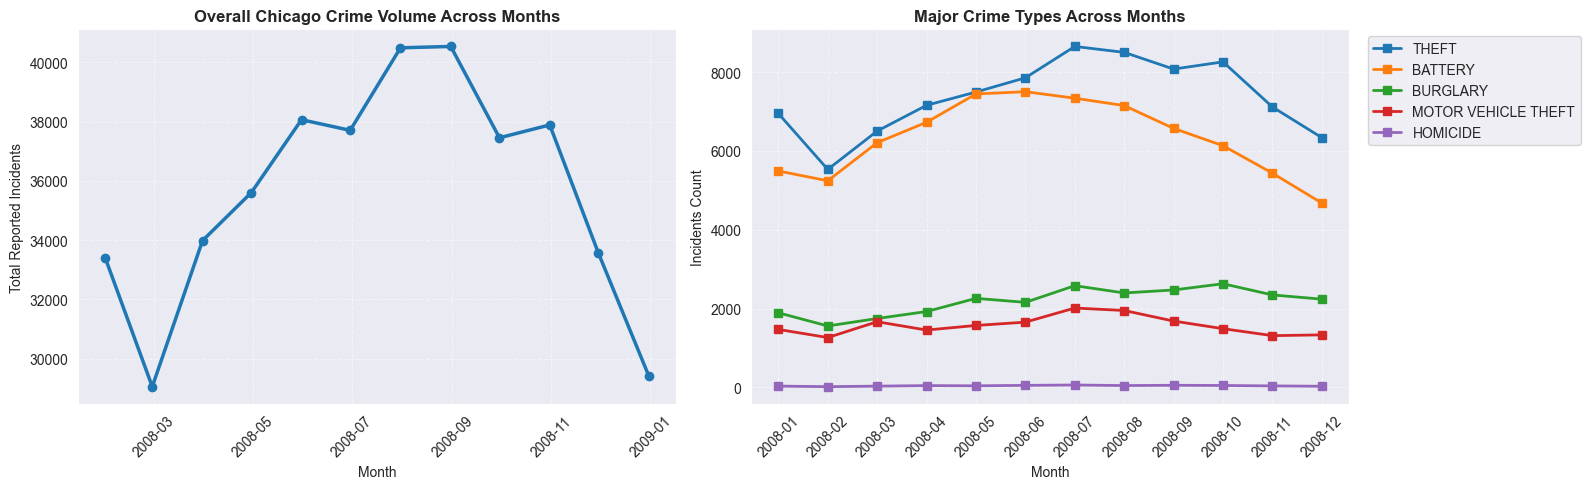

In [74]:
# Plotting Monthly Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Overall Monthly Crime Volume
axes[0].plot(
    monthly_total.index,
    monthly_total.values,
    marker="o",
    linewidth=2.5,
)

axes[0].set_title(
    "Overall Chicago Crime Volume Across Months", fontweight="bold"
)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Reported Incidents")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Major Crime Types
for col in monthly_target.columns:
    axes[1].plot(
        monthly_target.index.astype(str),
        monthly_target[col],
        label=col,
        marker="s",
        linewidth=2,
    )
axes[0].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title(
    "Major Crime Types Across Months", fontweight="bold"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Incidents Count")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Is overall crime increasing or decreasing?

The overall crime volume does not show a consistent increasing or decreasing trend during 2008. It decreases sharply from January to February, then increases steadily and reaches its highest level around August–September. After that, crime decreases again through December.

Which individual crimes do the opposite?

based on this chart, there is no major crime type that consistently moves in the opposite direction of overall crime throughout 2008.

#### 2. Comparing AM vs. PM Rush Hour
##### We will compare  crime activity between morning rush hour (7 AM – 10 AM) and evening rush hour (4 PM – 7 PM).

In [83]:
df.columns

Index(['ID', 'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Latitude', 'Longitude'],
      dtype='str')

In [85]:
df["Hour"] = df.index.hour

In [86]:
am_rush = df[df["Hour"].between(7, 9)]
pm_rush = df[df["Hour"].between(16, 18)]

In [87]:
print("AM Rush Hour:", len(am_rush))
print("PM Rush Hour:", len(pm_rush))

AM Rush Hour: 42285
PM Rush Hour: 64569


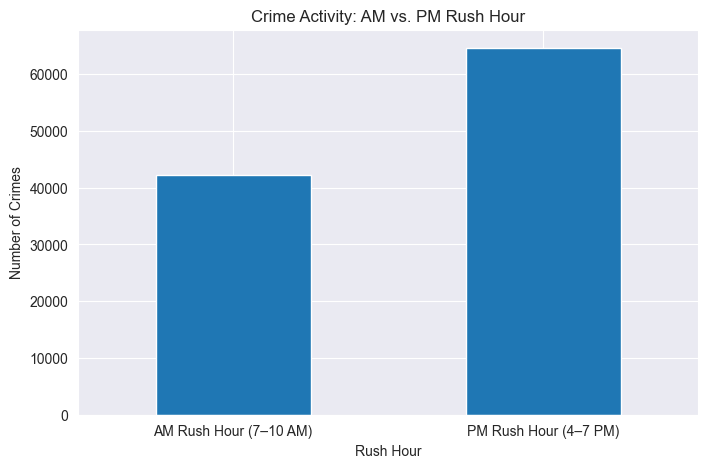

In [88]:
rush_hour = pd.Series({
    "AM Rush Hour (7–10 AM)": len(am_rush),
    "PM Rush Hour (4–7 PM)": len(pm_rush)
})

rush_hour.plot(kind="bar", figsize=(8, 5))

plt.title("Crime Activity: AM vs. PM Rush Hour")
plt.xlabel("Rush Hour")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)
plt.show()

In [89]:
am_crimes = am_rush["Primary Type"].value_counts()

print(am_crimes)

Primary Type
THEFT                               10566
BATTERY                              5382
BURGLARY                             4834
CRIMINAL DAMAGE                      4741
OTHER OFFENSE                        3404
DECEPTIVE PRACTICE                   2580
ASSAULT                              2384
MOTOR VEHICLE THEFT                  2341
NARCOTICS                            1725
CRIMINAL TRESPASS                    1218
ROBBERY                               987
PROSTITUTION                          809
OFFENSE INVOLVING CHILDREN            298
WEAPONS VIOLATION                     258
PUBLIC PEACE VIOLATION                187
SEX OFFENSE                           168
CRIM SEXUAL ASSAULT                   105
KIDNAPPING                             88
ARSON                                  46
INTIMIDATION                           44
STALKING                               33
HOMICIDE                               27
INTERFERENCE WITH PUBLIC OFFICER       21
GAMBLING             

In [90]:
pm_crimes = pm_rush["Primary Type"].value_counts()

print(pm_crimes)

Primary Type
THEFT                               15308
BATTERY                             11352
CRIMINAL DAMAGE                      7811
NARCOTICS                            5997
ASSAULT                              4511
BURGLARY                             3873
OTHER OFFENSE                        3822
ROBBERY                              2714
MOTOR VEHICLE THEFT                  2512
DECEPTIVE PRACTICE                   1953
CRIMINAL TRESPASS                    1835
OFFENSE INVOLVING CHILDREN            566
PUBLIC PEACE VIOLATION                505
WEAPONS VIOLATION                     472
PROSTITUTION                          276
GAMBLING                              244
SEX OFFENSE                           241
CRIM SEXUAL ASSAULT                   163
LIQUOR LAW VIOLATION                  114
INTERFERENCE WITH PUBLIC OFFICER       70
HOMICIDE                               58
KIDNAPPING                             53
ARSON                                  48
INTIMIDATION         

In [91]:
comparison = pd.DataFrame({
    "AM Rush Hour": am_crimes,
    "PM Rush Hour": pm_crimes
}).fillna(0)

comparison

,AM Rush Hour,PM Rush Hour
Primary Type,,
ARSON,46.0,48
ASSAULT,2384.0,4511
BATTERY,5382.0,11352
BURGLARY,4834.0,3873
CRIM SEXUAL ASSAULT,105.0,163
CRIMINAL DAMAGE,4741.0,7811
CRIMINAL SEXUAL ASSAULT,2.0,3
CRIMINAL TRESPASS,1218.0,1835
DECEPTIVE PRACTICE,2580.0,1953


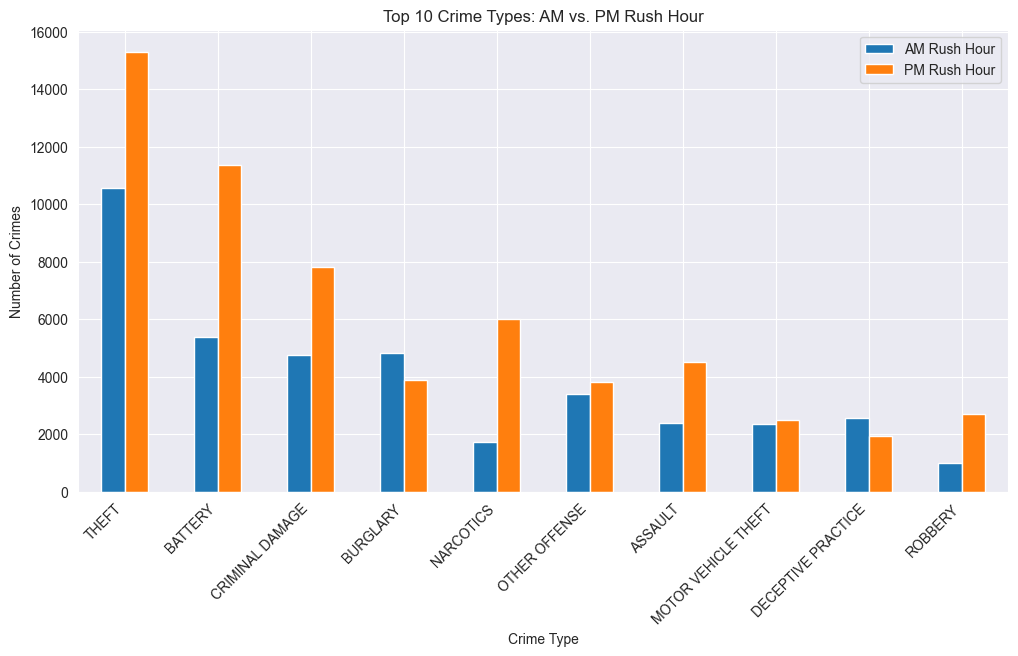

In [92]:
top10 = comparison.sum(axis=1).nlargest(10).index

comparison.loc[top10].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Crime Types: AM vs. PM Rush Hour")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.show()

Rush Hour Volume
PM Rush Hour dominates total crime: Crimes occurring during PM Rush Hour (64,000 incidents) are substantially higher—over 50% more frequent—than during AM Rush Hour (42,000 incidents).

#### 3. Seasonality & Time Series Decomposition
##### We will use statsmodels on the daily aggregated count series to isolate repeating annual cycles and measure their magnitude.

In [93]:
print(df.index.min())
print(df.index.max())

2008-01-01 00:00:00
2008-12-31 23:59:00


In [94]:
# we will choose Weekly seasonality
daily_crime = df.resample("D").size()

In [96]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_crime,
    model="additive",
    period=7
)

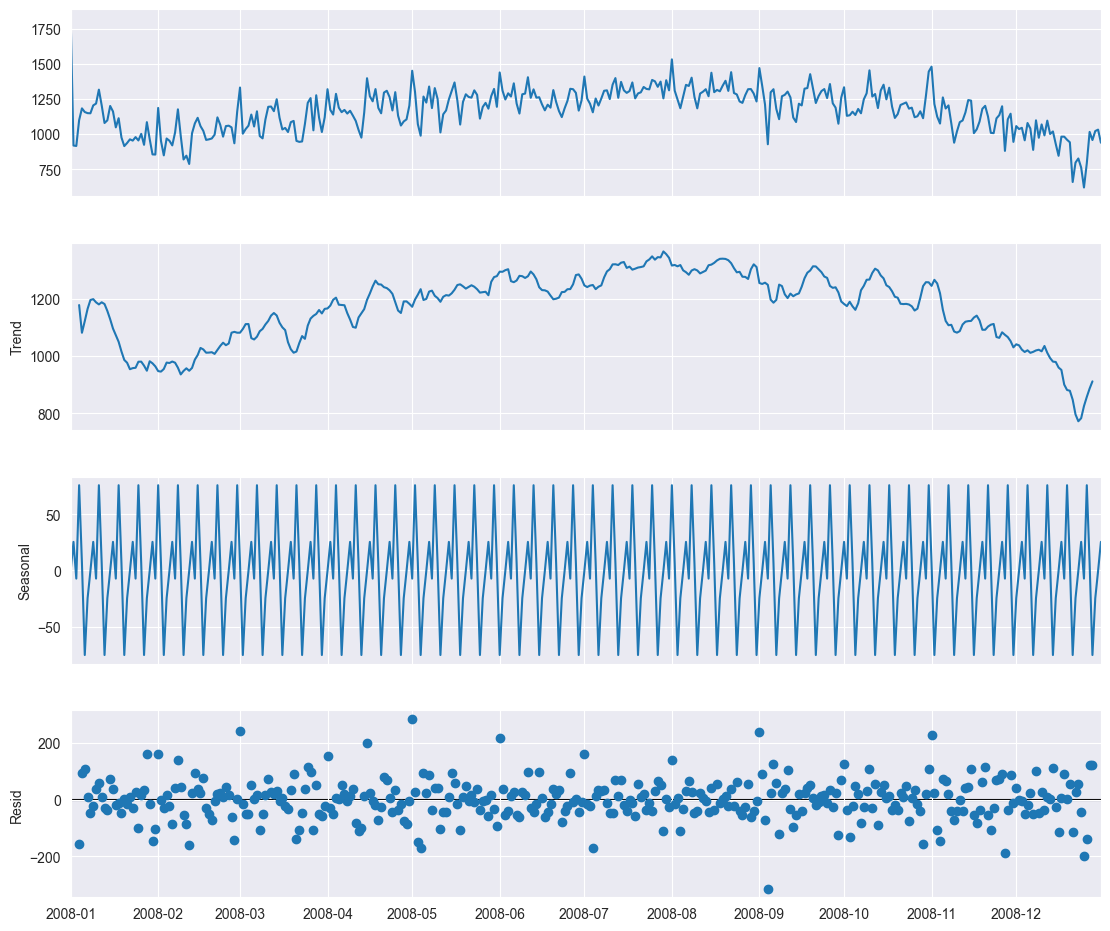

In [100]:
fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.show()

In [105]:
seasonal = decomposition.seasonal

magnitude = seasonal.max() - seasonal.min()

print(magnitude)

150.967032967033


In [106]:
print("Max seasonal effect:", seasonal.max())
print("Min seasonal effect:", seasonal.min())

Max seasonal effect: 75.78187428817681
Min seasonal effect: -75.18515867885617


7-Day Cycle Duration: Applying a 7-day period isolates a clear weekly seasonal cycle, with incident spikes aligned with weekends and troughs during midweek days.

Seasonal Magnitude: The net volume swing spans 150 crimes per day across the 7-day cycle (ranging from $+75$ incidents above baseline on peak days down to $-75$ incidents below baseline on off-peak days).